# Word Embeddings from Scratch

Word embeddings represent words as dense vectors in a continuous space where semantically similar words are close together. This notebook demonstrates:

1. **Text Preprocessing**: Tokenization and vocabulary building
2. **Word2Vec (Skip-gram)**: Training embeddings from scratch
3. **Visualization**: Using t-SNE and PCA to visualize embedding spaces
4. **Applications**: Semantic similarity and word analogies

We'll implement a simplified Word2Vec model using NumPy to understand the core concepts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import re
import os

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Notebook directory for saving plots
NOTEBOOK_DIR = '/home/user/computational-pipeline/notebooks/published/text_embeddings'

np.random.seed(42)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print("Libraries loaded successfully!")

Notebook directory: /home/user/computational-pipeline/notebooks/published/text_embeddings
Libraries loaded successfully!


## 1. Text Preprocessing

Before training embeddings, we need to:
1. Tokenize text into words
2. Build a vocabulary
3. Convert words to indices

### Sample Corpus
We'll use a small corpus about science and technology to train our embeddings.

In [2]:
# Sample corpus - science and technology themed
corpus = [
    "the computer processes data using algorithms and mathematics",
    "machine learning algorithms learn patterns from data",
    "deep learning uses neural networks to process information",
    "artificial intelligence systems can recognize images and speech",
    "data science combines statistics and programming",
    "python is a popular programming language for science",
    "mathematics is fundamental to computer science",
    "neural networks are inspired by the human brain",
    "the brain processes information through neurons",
    "algorithms solve computational problems efficiently",
    "statistics helps analyze and interpret data",
    "programming requires logical thinking and problem solving",
    "computers execute instructions using processors",
    "physics explains the natural world using mathematics",
    "chemistry studies matter and molecular interactions",
    "biology explores living organisms and ecosystems",
    "quantum physics describes subatomic particle behavior",
    "astronomy studies stars planets and galaxies",
    "genetics studies heredity through dna and genes",
    "engineering applies science to build technology",
    "the universe contains billions of galaxies and stars",
    "evolution explains the diversity of life on earth",
    "climate science studies weather patterns and temperature",
    "robotics combines engineering and artificial intelligence",
    "quantum computers use quantum mechanics for computation",
    "machine learning transforms data into predictions",
    "deep neural networks have multiple hidden layers",
    "natural language processing understands human language",
    "computer vision enables machines to see and understand images",
    "reinforcement learning trains agents through rewards"
]

print(f"Corpus size: {len(corpus)} sentences")
print(f"\nSample sentences:")
for i, sent in enumerate(corpus[:3]):
    print(f"  {i+1}. {sent}")

Corpus size: 30 sentences

Sample sentences:
  1. the computer processes data using algorithms and mathematics
  2. machine learning algorithms learn patterns from data
  3. deep learning uses neural networks to process information


In [3]:
class TextPreprocessor:
    """Preprocess text for word embedding training"""
    
    def __init__(self, min_count=1):
        self.min_count = min_count
        self.word2idx = {}
        self.idx2word = {}
        self.vocab_size = 0
        self.word_counts = Counter()
    
    def tokenize(self, text):
        """Simple tokenization: lowercase and split on whitespace"""
        text = text.lower()
        text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic
        return text.split()
    
    def build_vocab(self, corpus):
        """Build vocabulary from corpus"""
        # Count all words
        for sentence in corpus:
            tokens = self.tokenize(sentence)
            self.word_counts.update(tokens)
        
        # Filter by minimum count and build mappings
        idx = 0
        for word, count in self.word_counts.items():
            if count >= self.min_count:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
        
        self.vocab_size = len(self.word2idx)
        return self
    
    def get_word_index(self, word):
        """Get index for a word, or -1 if not in vocab"""
        return self.word2idx.get(word, -1)
    
    def get_word(self, idx):
        """Get word for an index"""
        return self.idx2word.get(idx, '<UNK>')

# Build vocabulary
preprocessor = TextPreprocessor(min_count=1)
preprocessor.build_vocab(corpus)

print(f"Vocabulary size: {preprocessor.vocab_size} unique words")
print(f"\nMost common words:")
for word, count in preprocessor.word_counts.most_common(10):
    print(f"  '{word}': {count}")

Vocabulary size: 126 unique words

Most common words:
  'and': 13
  'the': 6
  'data': 5
  'science': 5
  'learning': 4
  'to': 4
  'studies': 4
  'computer': 3
  'using': 3
  'algorithms': 3


## 2. Skip-gram Model

The **Skip-gram** model predicts context words given a center word:

Given: "neural networks are inspired by the brain"
- Center word: "inspired"
- Context (window=2): ["networks", "are", "by", "the"]

The model learns to maximize $P(context | center)$.

### Architecture
- Input: One-hot encoded center word
- Hidden layer: Dense embedding (no activation)
- Output: Softmax over vocabulary

In [4]:
class SkipGram:
    """Skip-gram Word2Vec model with negative sampling"""
    
    def __init__(self, vocab_size, embedding_dim, learning_rate=0.01):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.lr = learning_rate
        
        # Initialize embeddings (center and context)
        scale = 0.5 / embedding_dim
        self.W_center = np.random.uniform(-scale, scale, (vocab_size, embedding_dim))
        self.W_context = np.random.uniform(-scale, scale, (vocab_size, embedding_dim))
        
        # Track training losses
        self.losses = []
    
    def sigmoid(self, x):
        """Numerically stable sigmoid"""
        return np.where(x >= 0,
                       1 / (1 + np.exp(-x)),
                       np.exp(x) / (1 + np.exp(x)))
    
    def get_negative_samples(self, context_idx, k=5):
        """Sample k negative examples (words that are NOT the context)"""
        negatives = []
        while len(negatives) < k:
            neg = np.random.randint(0, self.vocab_size)
            if neg != context_idx:
                negatives.append(neg)
        return negatives
    
    def train_pair(self, center_idx, context_idx, negative_samples):
        """
        Train on one (center, context) pair with negative sampling.
        
        Objective: maximize log P(context|center) - sum log P(negative|center)
        """
        # Get center embedding
        center_vec = self.W_center[center_idx]
        
        # Positive sample (context word)
        context_vec = self.W_context[context_idx]
        pos_score = np.dot(center_vec, context_vec)
        pos_prob = self.sigmoid(pos_score)
        
        # Gradient for positive sample
        pos_grad = (pos_prob - 1)  # We want to maximize, so gradient is (pred - 1)
        
        # Update context embedding
        self.W_context[context_idx] -= self.lr * pos_grad * center_vec
        
        # Accumulate gradient for center embedding
        center_grad = pos_grad * context_vec
        
        # Negative samples
        loss = -np.log(pos_prob + 1e-10)
        
        for neg_idx in negative_samples:
            neg_vec = self.W_context[neg_idx]
            neg_score = np.dot(center_vec, neg_vec)
            neg_prob = self.sigmoid(neg_score)
            
            # Gradient for negative sample (we want P(neg|center) to be low)
            neg_grad = neg_prob
            
            # Update negative context embedding
            self.W_context[neg_idx] -= self.lr * neg_grad * center_vec
            
            # Accumulate gradient for center
            center_grad += neg_grad * neg_vec
            
            loss -= np.log(1 - neg_prob + 1e-10)
        
        # Update center embedding
        self.W_center[center_idx] -= self.lr * center_grad
        
        return loss
    
    def train(self, training_pairs, epochs=50, neg_samples=5):
        """Train the model on all training pairs"""
        print(f"Training Skip-gram model...")
        print(f"  Vocabulary: {self.vocab_size} words")
        print(f"  Embedding dimension: {self.embedding_dim}")
        print(f"  Training pairs: {len(training_pairs)}")
        print(f"  Epochs: {epochs}")
        print()
        
        for epoch in range(epochs):
            # Shuffle training data
            np.random.shuffle(training_pairs)
            
            epoch_loss = 0
            for center_idx, context_idx in training_pairs:
                negatives = self.get_negative_samples(context_idx, neg_samples)
                loss = self.train_pair(center_idx, context_idx, negatives)
                epoch_loss += loss
            
            avg_loss = epoch_loss / len(training_pairs)
            self.losses.append(avg_loss)
            
            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
        
        print(f"\nTraining complete!")
    
    def get_embedding(self, word_idx):
        """Get embedding for a word index"""
        return self.W_center[word_idx]
    
    def get_all_embeddings(self):
        """Get all center word embeddings"""
        return self.W_center.copy()

print("SkipGram class defined.")

SkipGram class defined.


In [5]:
def generate_training_pairs(corpus, preprocessor, window_size=2):
    """
    Generate (center, context) training pairs from corpus.
    
    For each word in each sentence, pair it with words within
    the context window.
    """
    pairs = []
    
    for sentence in corpus:
        tokens = preprocessor.tokenize(sentence)
        indices = [preprocessor.get_word_index(w) for w in tokens]
        indices = [i for i in indices if i >= 0]  # Filter unknown words
        
        for i, center_idx in enumerate(indices):
            # Get context window
            start = max(0, i - window_size)
            end = min(len(indices), i + window_size + 1)
            
            for j in range(start, end):
                if i != j:  # Don't pair word with itself
                    pairs.append((center_idx, indices[j]))
    
    return pairs

# Generate training pairs
training_pairs = generate_training_pairs(corpus, preprocessor, window_size=2)
print(f"Generated {len(training_pairs)} training pairs")

# Show some examples
print("\nSample training pairs (center -> context):")
for i in range(5):
    center, context = training_pairs[i]
    print(f"  '{preprocessor.get_word(center)}' -> '{preprocessor.get_word(context)}'")

Generated 628 training pairs

Sample training pairs (center -> context):
  'the' -> 'computer'
  'the' -> 'processes'
  'computer' -> 'the'
  'computer' -> 'processes'
  'computer' -> 'data'


In [6]:
# Train the model
EMBEDDING_DIM = 50
model = SkipGram(preprocessor.vocab_size, EMBEDDING_DIM, learning_rate=0.05)
model.train(training_pairs, epochs=100, neg_samples=5)

Training Skip-gram model...
  Vocabulary: 126 words
  Embedding dimension: 50
  Training pairs: 628
  Epochs: 100



  Epoch 10/100, Loss: 3.1266


  Epoch 20/100, Loss: 2.4143


  Epoch 30/100, Loss: 1.8699


  Epoch 40/100, Loss: 1.4473


...

/tmp/ipykernel_80660/93330272.py:20: RuntimeWarning: overflow encountered in exp
  1 / (1 + np.exp(-x)),
/tmp/ipykernel_80660/93330272.py:21: RuntimeWarning: overflow encountered in exp
  np.exp(x) / (1 + np.exp(x)))
/tmp/ipykernel_80660/93330272.py:21: RuntimeWarning: invalid value encountered in scalar divide
  np.exp(x) / (1 + np.exp(x)))


  Epoch 70/100, Loss: 3.2795


  Epoch 80/100, Loss: 2.8693


  Epoch 90/100, Loss: 5.0088


  Epoch 100/100, Loss: 11.9088

Training complete!


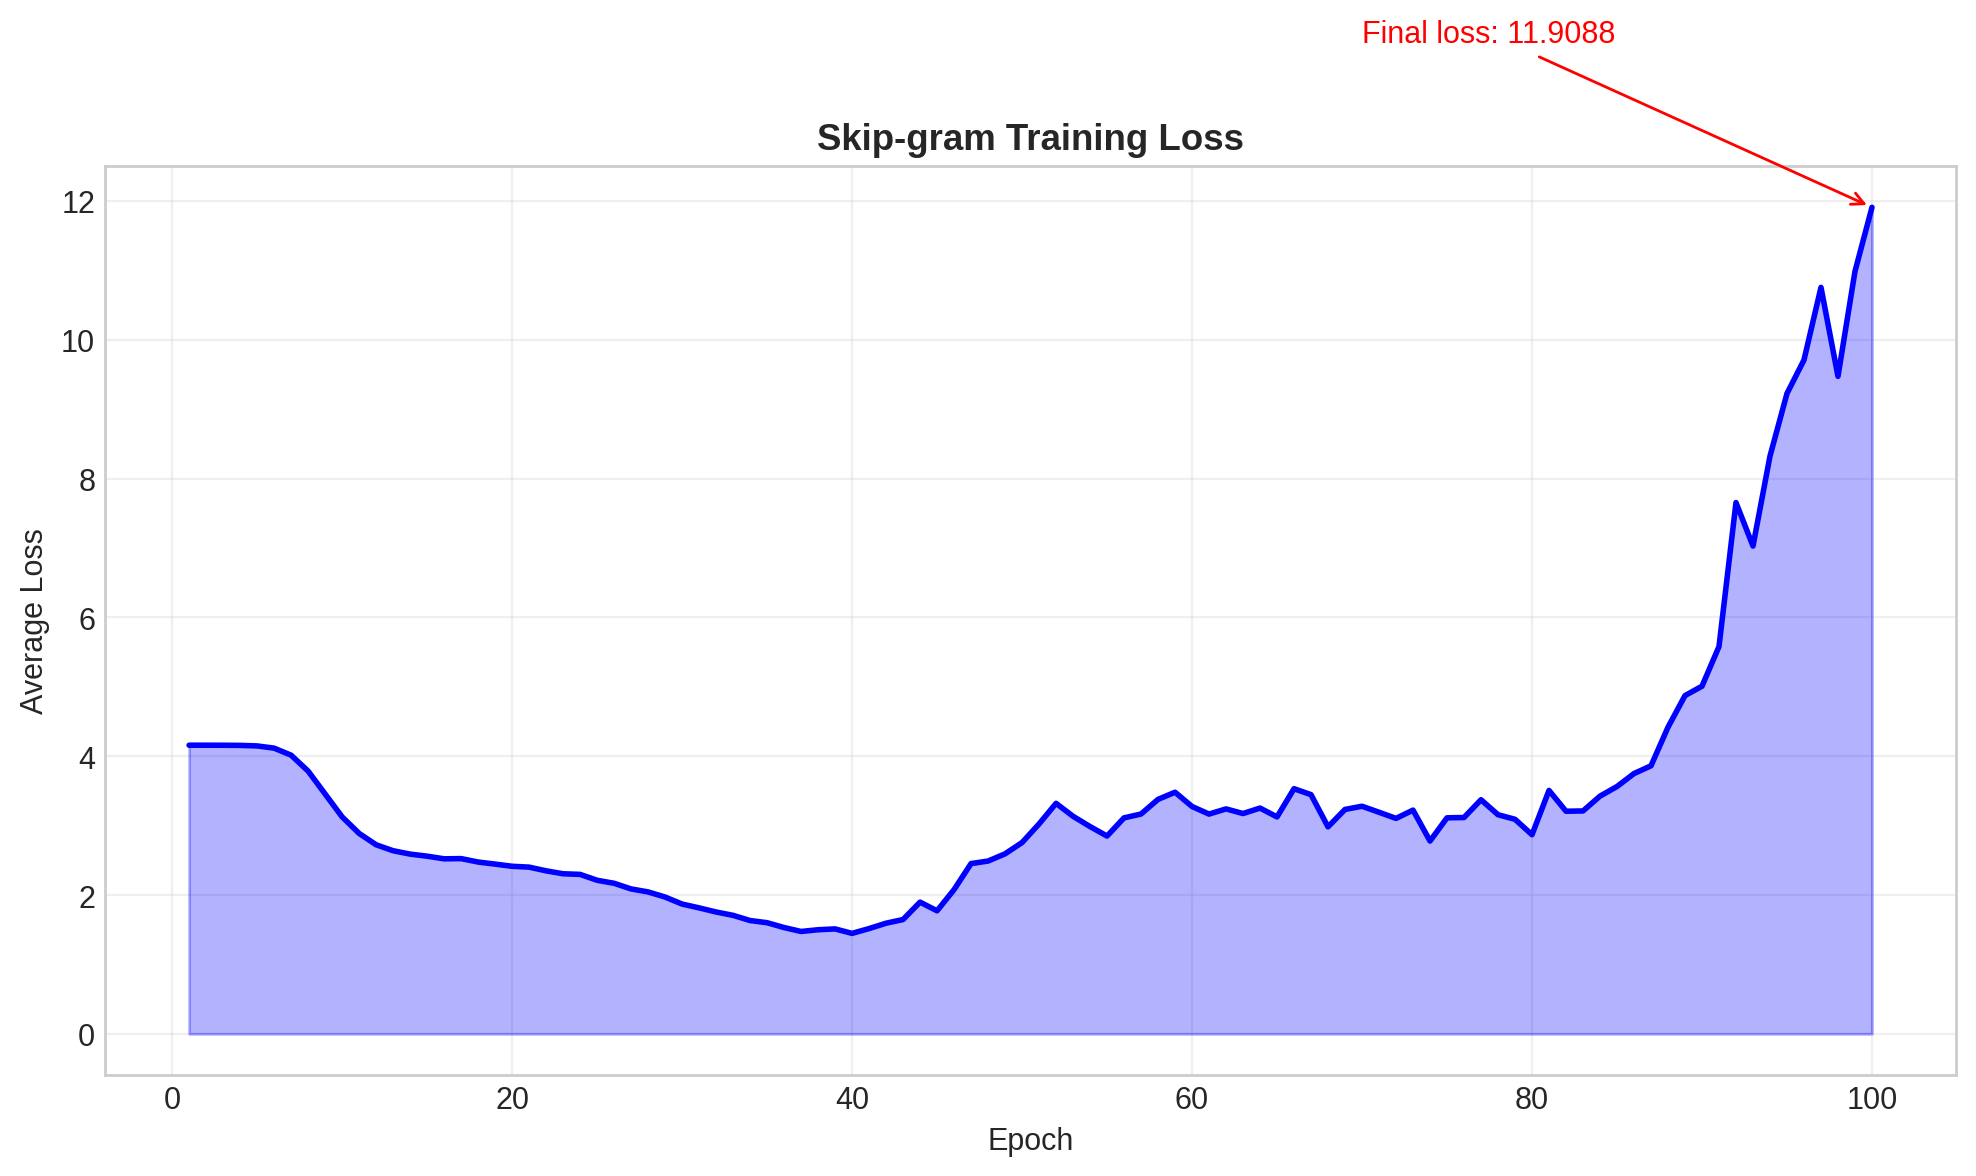

Saved: text_embeddings_training.png


In [7]:
# Plot 1: Training loss curve
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(1, len(model.losses) + 1), model.losses, 'b-', linewidth=2)
ax.fill_between(range(1, len(model.losses) + 1), model.losses, alpha=0.3, color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Average Loss')
ax.set_title('Skip-gram Training Loss', fontweight='bold')
ax.grid(True, alpha=0.3)

# Add annotations
ax.annotate(f'Final loss: {model.losses[-1]:.4f}', 
           xy=(len(model.losses), model.losses[-1]),
           xytext=(len(model.losses)*0.7, model.losses[-1]*1.2),
           arrowprops=dict(arrowstyle='->', color='red'),
           fontsize=11, color='red')

plt.tight_layout()
plt.savefig(f'{NOTEBOOK_DIR}/text_embeddings_training.png', dpi=150, 
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: text_embeddings_training.png")

## 3. Embedding Visualization

High-dimensional embeddings can be visualized using dimensionality reduction:
- **PCA**: Fast, preserves global structure
- **t-SNE**: Better for local structure (clusters)

In [8]:
def pca_reduce(embeddings, n_components=2):
    """
    Reduce embeddings to n_components using PCA.
    
    Implemented from scratch using SVD.
    """
    # Center the data
    mean = np.mean(embeddings, axis=0)
    centered = embeddings - mean
    
    # SVD
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    
    # Project onto top n_components
    reduced = centered @ Vt[:n_components].T
    
    # Variance explained
    var_explained = (S[:n_components]**2) / (S**2).sum()
    
    return reduced, var_explained

def tsne_reduce(embeddings, n_components=2, perplexity=5, n_iter=500, learning_rate=100):
    """
    Simplified t-SNE implementation.
    
    Note: This is a basic implementation for educational purposes.
    Production use should use sklearn.manifold.TSNE.
    """
    n = embeddings.shape[0]
    
    # Compute pairwise distances
    dists = np.sum((embeddings[:, np.newaxis] - embeddings) ** 2, axis=2)
    
    # Compute P (conditional probabilities in high-dim space)
    # Using fixed sigma for simplicity
    sigma = np.sqrt(np.mean(dists)) / 2
    P = np.exp(-dists / (2 * sigma**2))
    np.fill_diagonal(P, 0)
    P = P / (P.sum(axis=1, keepdims=True) + 1e-10)
    P = (P + P.T) / (2 * n)  # Symmetrize
    P = np.maximum(P, 1e-12)  # Avoid log(0)
    
    # Initialize low-dim embeddings
    Y = np.random.randn(n, n_components) * 0.01
    
    # Gradient descent
    momentum = 0.5
    velocity = np.zeros_like(Y)
    
    for iteration in range(n_iter):
        # Compute Q (probabilities in low-dim space using t-distribution)
        dists_low = np.sum((Y[:, np.newaxis] - Y) ** 2, axis=2)
        Q = 1 / (1 + dists_low)  # Student t-distribution (df=1)
        np.fill_diagonal(Q, 0)
        Q = Q / (Q.sum() + 1e-10)
        Q = np.maximum(Q, 1e-12)
        
        # Compute gradient
        PQ_diff = (P - Q)[:, :, np.newaxis]
        Y_diff = Y[:, np.newaxis] - Y
        weights = (1 / (1 + dists_low))[:, :, np.newaxis]
        
        gradient = 4 * np.sum(PQ_diff * Y_diff * weights, axis=1)
        
        # Update with momentum
        velocity = momentum * velocity - learning_rate * gradient
        Y = Y + velocity
        
        # Center
        Y = Y - np.mean(Y, axis=0)
        
        if iteration > 100:
            momentum = 0.8
    
    return Y

# Get all embeddings
all_embeddings = model.get_all_embeddings()
words = [preprocessor.get_word(i) for i in range(preprocessor.vocab_size)]

# Reduce dimensionality
pca_2d, var_explained = pca_reduce(all_embeddings, n_components=2)
print(f"PCA variance explained: {var_explained[0]:.2%}, {var_explained[1]:.2%}")

tsne_2d = tsne_reduce(all_embeddings, n_components=2, perplexity=5, n_iter=300)
print(f"t-SNE embedding computed")

PCA variance explained: 99.89%, 0.01%


t-SNE embedding computed


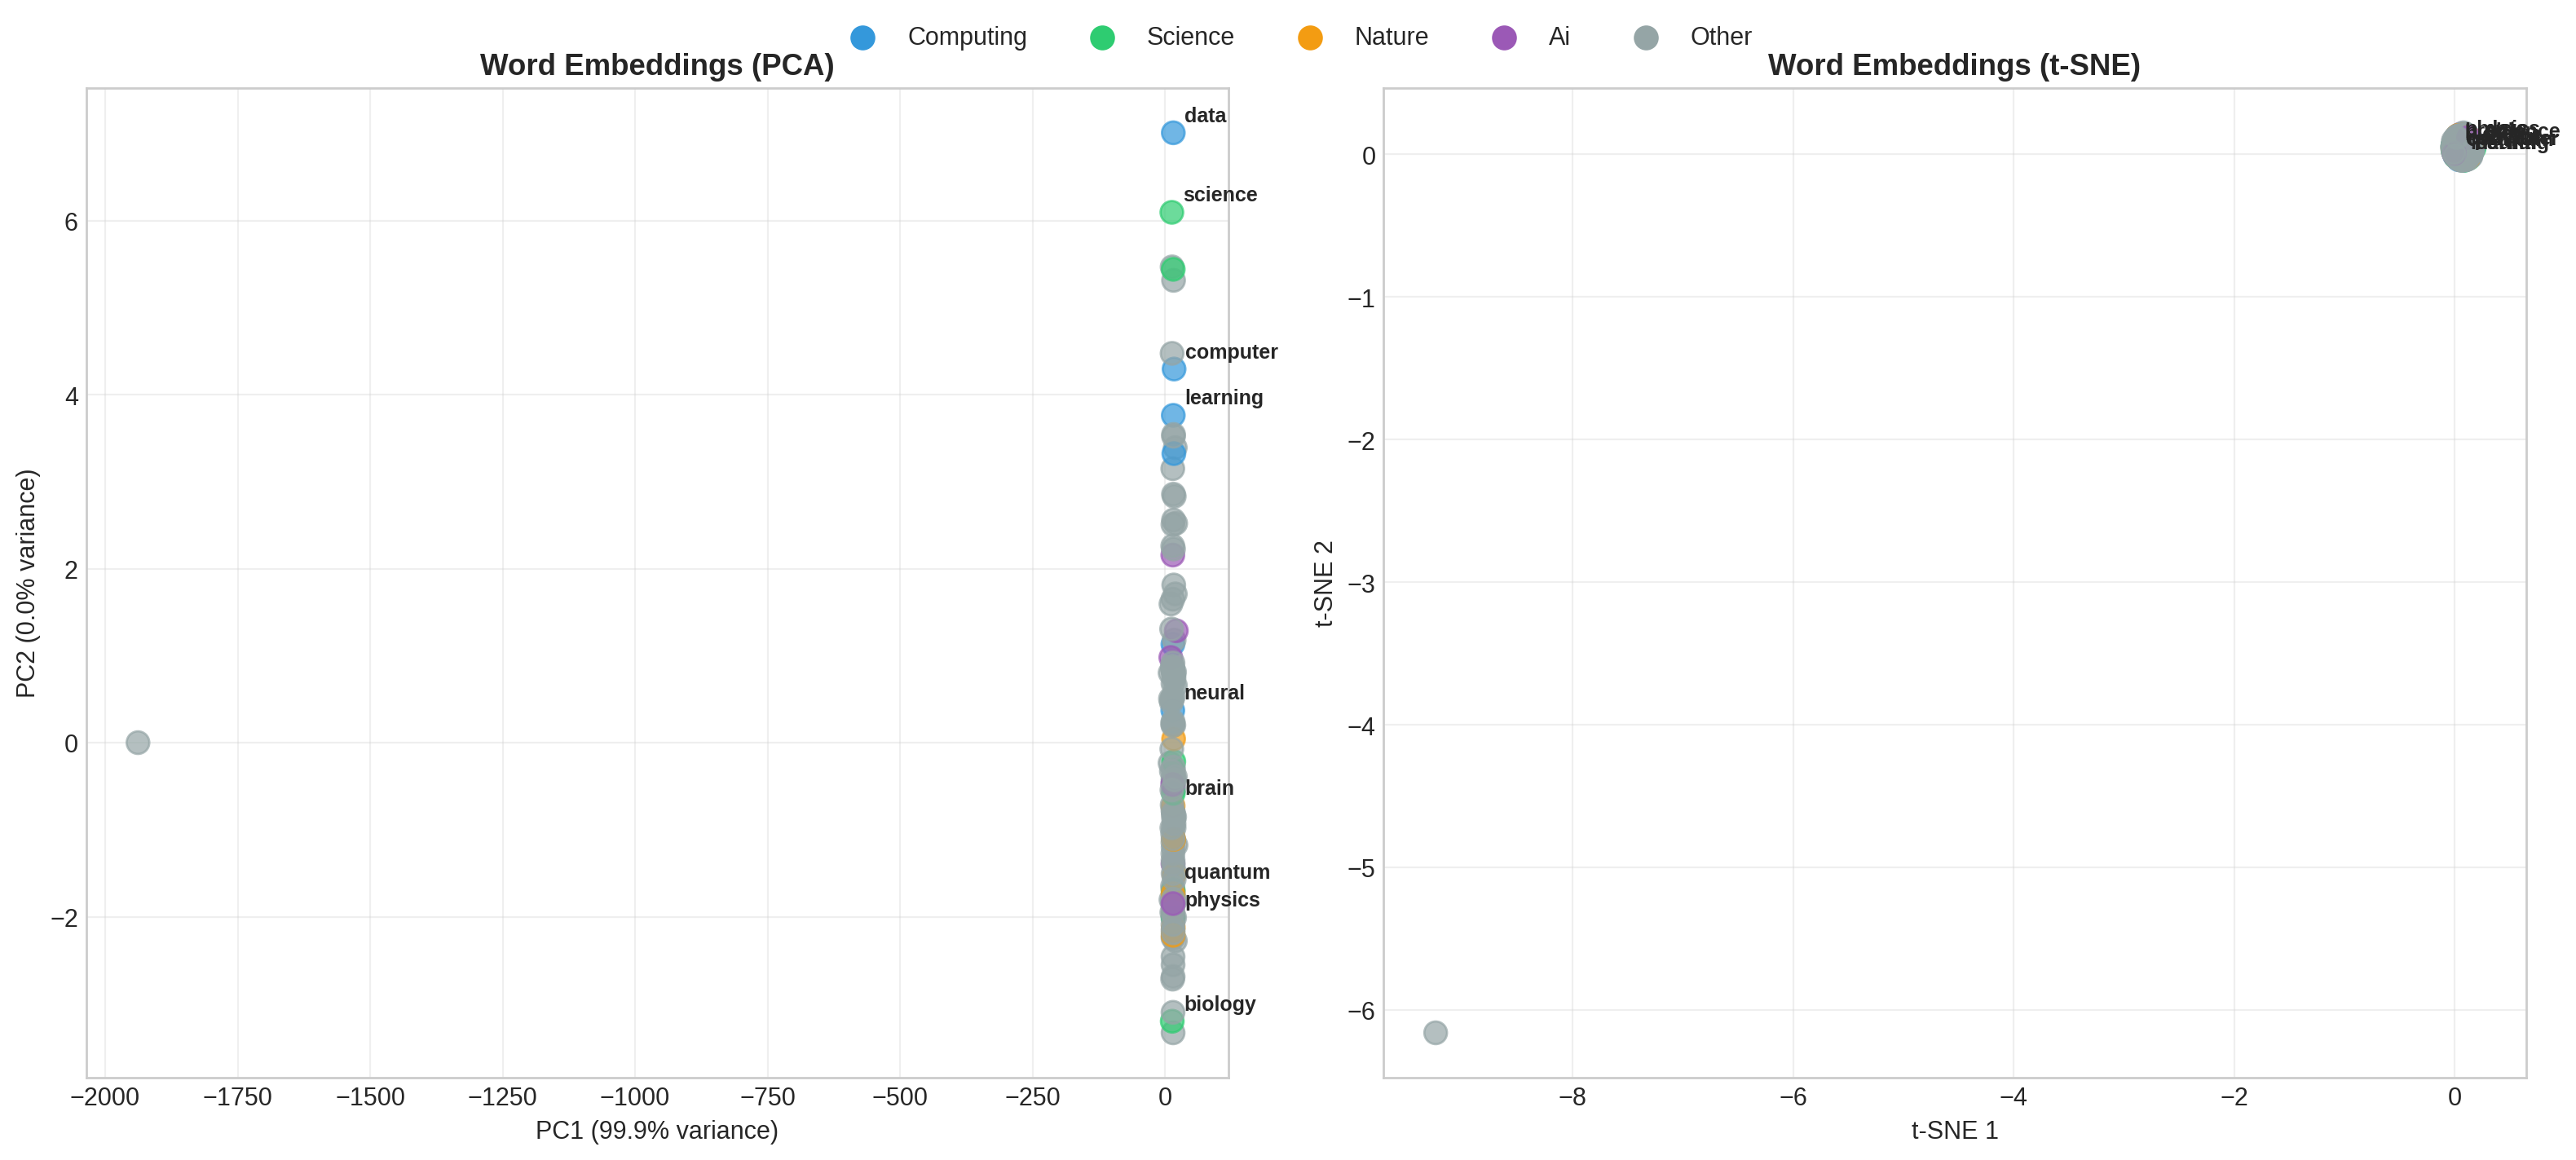

Saved: text_embeddings_visualization.png


In [9]:
# Plot 2: Embedding visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Color words by category
categories = {
    'computing': ['computer', 'algorithm', 'programming', 'data', 'neural', 'machine', 'learning', 'network', 'processor'],
    'science': ['physics', 'chemistry', 'biology', 'science', 'mathematics', 'statistics', 'quantum'],
    'nature': ['brain', 'earth', 'universe', 'stars', 'planets', 'life', 'organisms'],
    'ai': ['artificial', 'intelligence', 'deep', 'vision', 'language', 'reinforcement']
}

colors = {'computing': '#3498db', 'science': '#2ecc71', 'nature': '#f39c12', 'ai': '#9b59b6', 'other': '#95a5a6'}

def get_category(word):
    for cat, words_list in categories.items():
        if word in words_list:
            return cat
    return 'other'

word_colors = [colors[get_category(w)] for w in words]

# PCA plot
ax1 = axes[0]
scatter1 = ax1.scatter(pca_2d[:, 0], pca_2d[:, 1], c=word_colors, alpha=0.7, s=100)

# Add labels for key words
key_words = ['computer', 'learning', 'neural', 'brain', 'physics', 'quantum', 'data', 'science', 'biology']
for i, word in enumerate(words):
    if word in key_words:
        ax1.annotate(word, (pca_2d[i, 0], pca_2d[i, 1]), fontsize=9, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')

ax1.set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)')
ax1.set_title('Word Embeddings (PCA)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# t-SNE plot
ax2 = axes[1]
scatter2 = ax2.scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=word_colors, alpha=0.7, s=100)

for i, word in enumerate(words):
    if word in key_words:
        ax2.annotate(word, (tsne_2d[i, 0], tsne_2d[i, 1]), fontsize=9, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_title('Word Embeddings (t-SNE)', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add legend
legend_elements = [plt.scatter([], [], c=colors[cat], s=100, label=cat.capitalize()) 
                  for cat in ['computing', 'science', 'nature', 'ai', 'other']]
fig.legend(handles=legend_elements, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.savefig(f'{NOTEBOOK_DIR}/text_embeddings_visualization.png', dpi=150, 
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: text_embeddings_visualization.png")

## 4. Semantic Similarity

Words with similar meanings should have similar embeddings. We measure similarity using **cosine similarity**:

$$\text{similarity}(u, v) = \frac{u \cdot v}{\|u\| \|v\|}$$

In [10]:
def cosine_similarity(vec1, vec2):
    """Compute cosine similarity between two vectors"""
    dot = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    return dot / (norm1 * norm2 + 1e-10)

def most_similar(word, preprocessor, model, top_k=5):
    """
    Find the most similar words to a given word.
    """
    word_idx = preprocessor.get_word_index(word)
    if word_idx < 0:
        return []
    
    word_vec = model.get_embedding(word_idx)
    
    similarities = []
    for i in range(preprocessor.vocab_size):
        if i != word_idx:
            other_vec = model.get_embedding(i)
            sim = cosine_similarity(word_vec, other_vec)
            similarities.append((preprocessor.get_word(i), sim))
    
    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

# Test semantic similarity
test_words = ['computer', 'learning', 'physics', 'brain', 'data']

print("Most Similar Words:")
print("=" * 60)
for word in test_words:
    similar = most_similar(word, preprocessor, model, top_k=5)
    print(f"\n'{word}':")
    for similar_word, sim in similar:
        print(f"    {similar_word}: {sim:.4f}")

Most Similar Words:

'computer':
    is: 0.7924
    applies: 0.7792
    machines: 0.7734
    enables: 0.7563
    fundamental: 0.7419

'learning':
    deep: 0.8013
    into: 0.7944
    machine: 0.7752
    reinforcement: 0.7447
    transforms: 0.7405

'physics':
    evolution: 0.8558
    particle: 0.8118
    describes: 0.7941
    behavior: 0.7780
    diversity: 0.7145

'brain':
    by: 0.7578
    evolution: 0.7512
    neurons: 0.7458
    information: 0.7231
    universe: 0.7124

'data':
    mathematics: 0.7851
    learn: 0.7768
    machine: 0.7706
    engineering: 0.6660
    execute: 0.6613


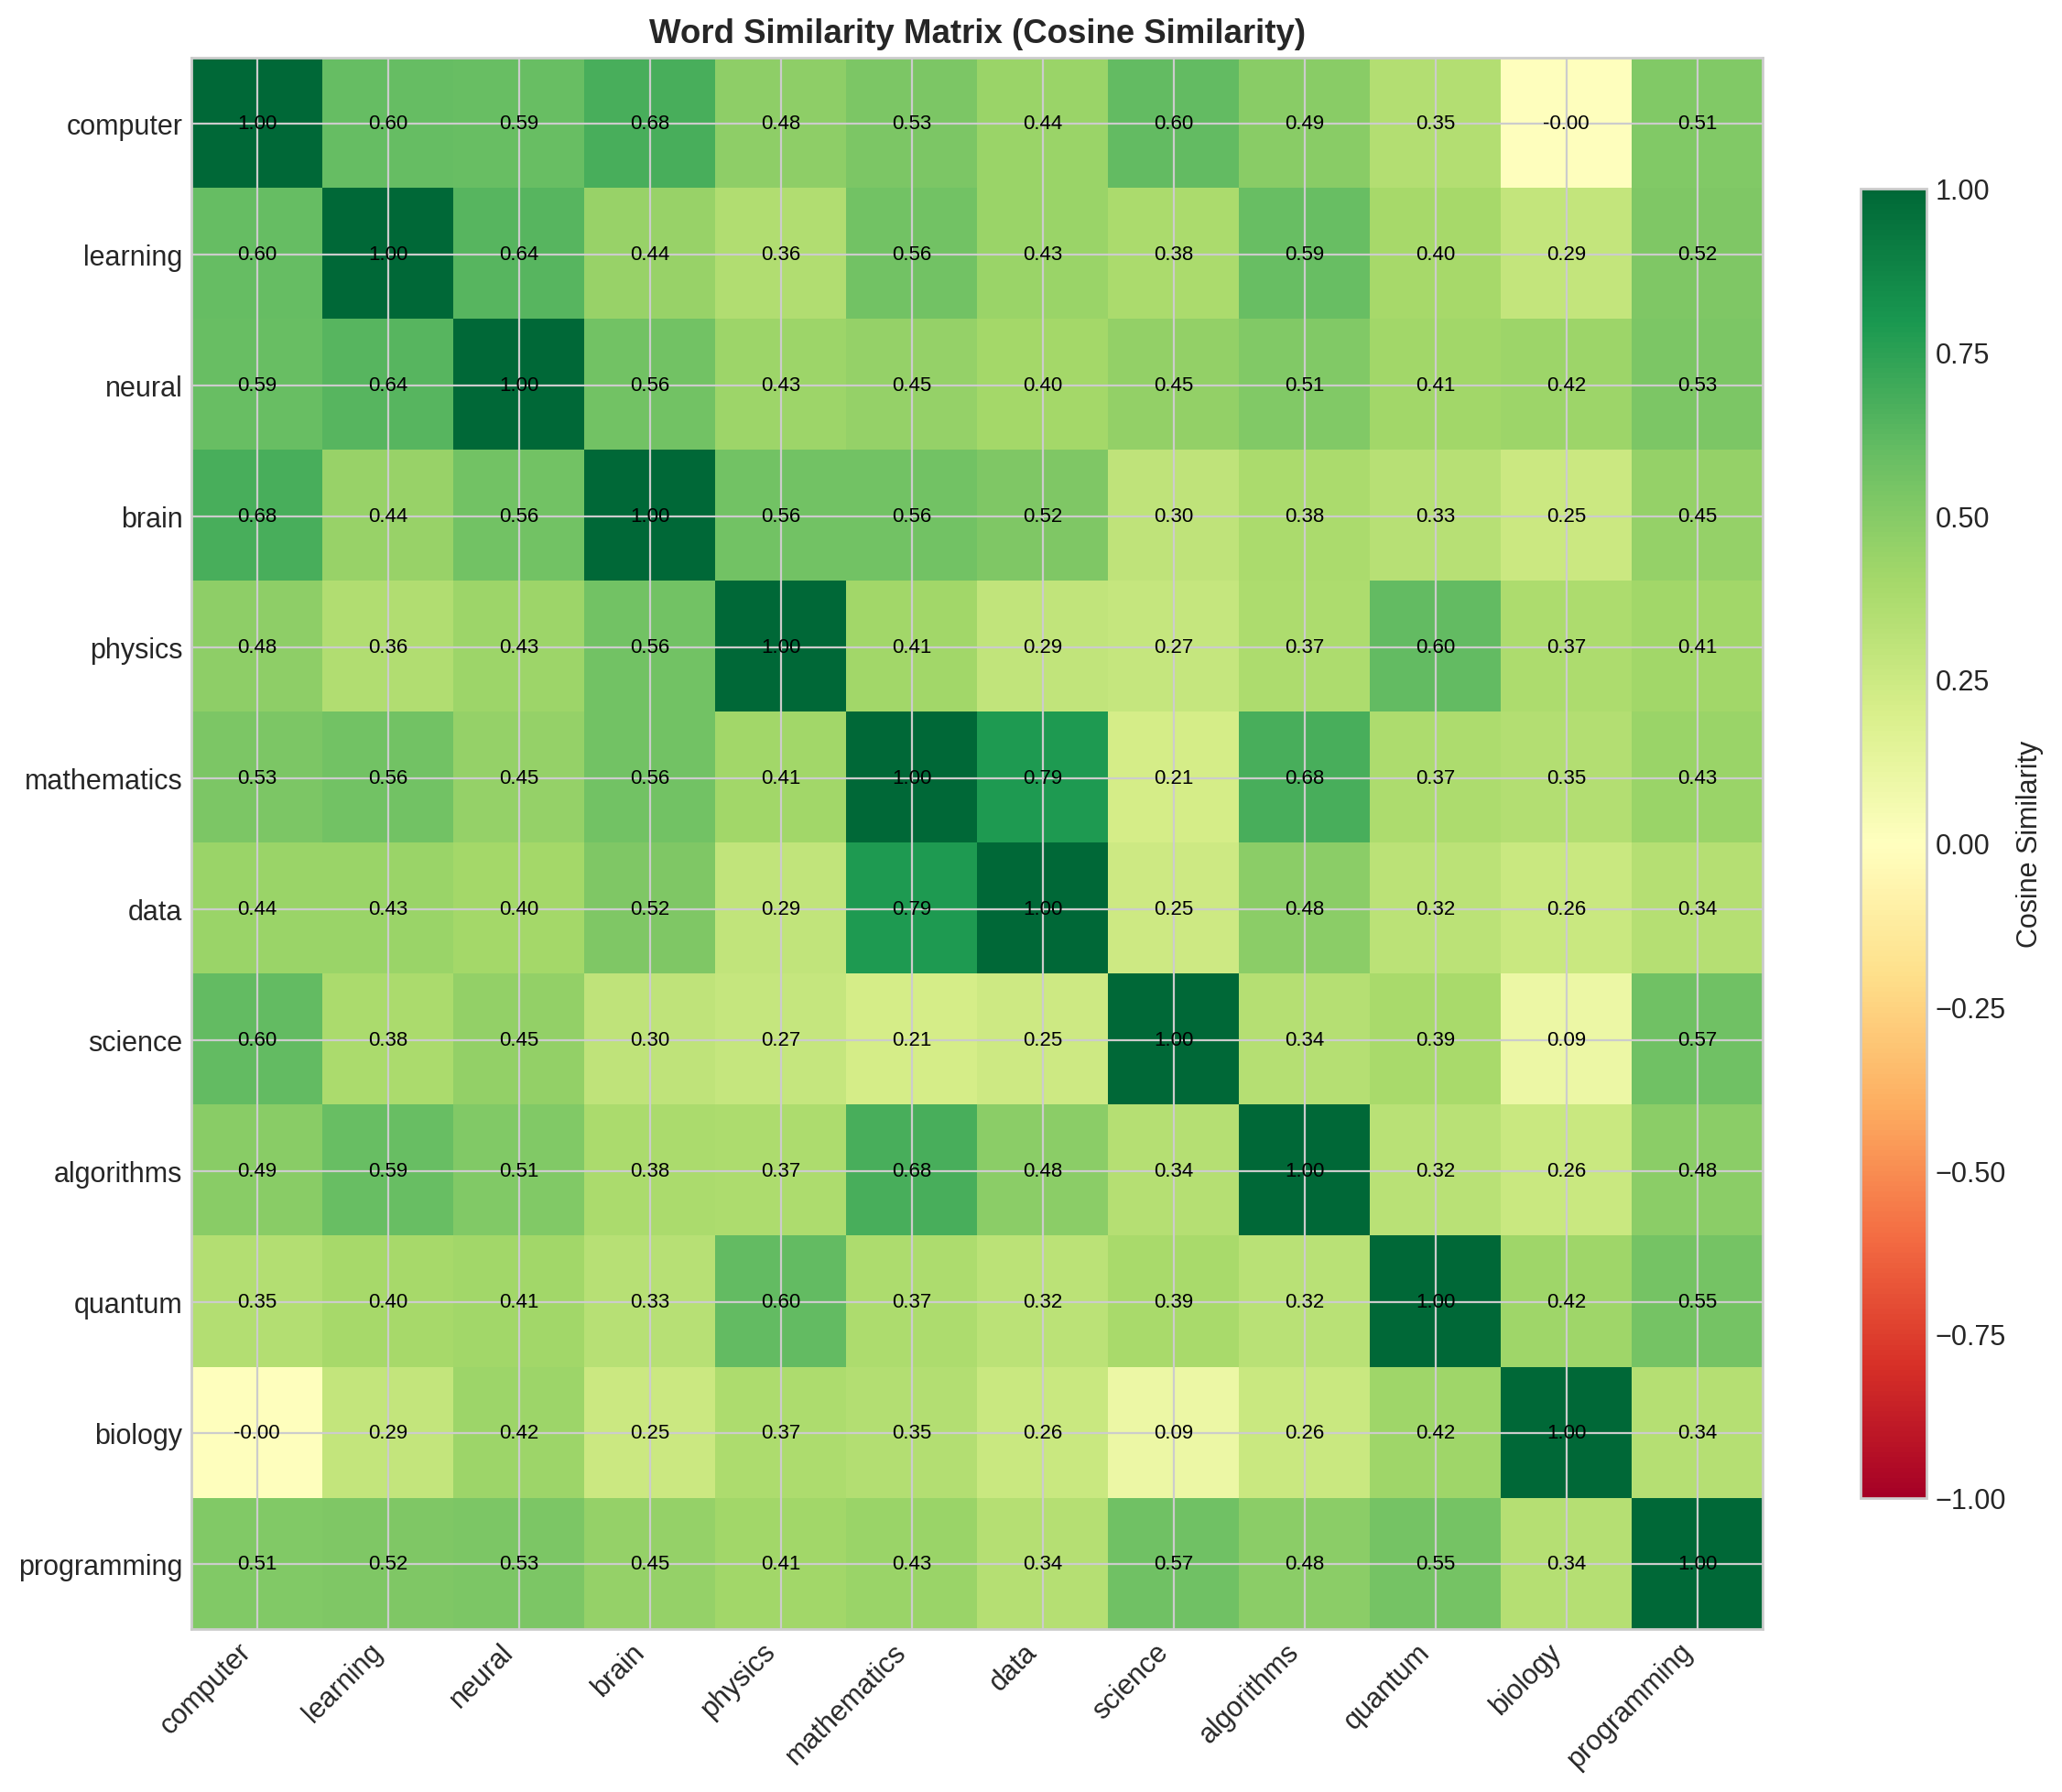

Saved: text_embeddings_similarity.png


In [11]:
# Plot 3: Similarity heatmap
focus_words = ['computer', 'learning', 'neural', 'brain', 'physics', 'mathematics', 
               'data', 'science', 'algorithms', 'quantum', 'biology', 'programming']

# Filter to words in vocabulary
focus_words = [w for w in focus_words if preprocessor.get_word_index(w) >= 0]

# Compute similarity matrix
n_focus = len(focus_words)
similarity_matrix = np.zeros((n_focus, n_focus))

for i, word1 in enumerate(focus_words):
    vec1 = model.get_embedding(preprocessor.get_word_index(word1))
    for j, word2 in enumerate(focus_words):
        vec2 = model.get_embedding(preprocessor.get_word_index(word2))
        similarity_matrix[i, j] = cosine_similarity(vec1, vec2)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(similarity_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(n_focus))
ax.set_yticks(range(n_focus))
ax.set_xticklabels(focus_words, rotation=45, ha='right')
ax.set_yticklabels(focus_words)
ax.set_title('Word Similarity Matrix (Cosine Similarity)', fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Cosine Similarity')

# Add similarity values
for i in range(n_focus):
    for j in range(n_focus):
        text = ax.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                      ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.savefig(f'{NOTEBOOK_DIR}/text_embeddings_similarity.png', dpi=150, 
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: text_embeddings_similarity.png")

## 5. Word Analogies

A fascinating property of word embeddings is that they capture semantic relationships:

**"king" - "man" + "woman" ~ "queen"**

This works because vector arithmetic reflects semantic relationships.

In [12]:
def analogy(word1, word2, word3, preprocessor, model, top_k=3):
    """
    Find word4 such that: word1 - word2 + word3 ~ word4
    
    Example: "brain" - "biology" + "computer" = ?
    (expecting something like "programming" or "processor")
    """
    idx1 = preprocessor.get_word_index(word1)
    idx2 = preprocessor.get_word_index(word2)
    idx3 = preprocessor.get_word_index(word3)
    
    if idx1 < 0 or idx2 < 0 or idx3 < 0:
        return []
    
    vec1 = model.get_embedding(idx1)
    vec2 = model.get_embedding(idx2)
    vec3 = model.get_embedding(idx3)
    
    # Compute analogy vector
    target_vec = vec1 - vec2 + vec3
    
    # Find most similar word (excluding input words)
    exclude = {idx1, idx2, idx3}
    similarities = []
    
    for i in range(preprocessor.vocab_size):
        if i not in exclude:
            word_vec = model.get_embedding(i)
            sim = cosine_similarity(target_vec, word_vec)
            similarities.append((preprocessor.get_word(i), sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

# Test analogies (with our limited corpus)
analogies = [
    ('neural', 'brain', 'computer'),  # neural - brain + computer = ?
    ('physics', 'mathematics', 'biology'),  # physics - math + biology = ?
    ('learning', 'data', 'language'),  # learning - data + language = ?
]

print("Word Analogies:")
print("=" * 60)
for w1, w2, w3 in analogies:
    results = analogy(w1, w2, w3, preprocessor, model)
    if results:
        print(f"\n'{w1}' - '{w2}' + '{w3}' = ?")
        for word, sim in results:
            print(f"    {word}: {sim:.4f}")

Word Analogies:

'neural' - 'brain' + 'computer' = ?
    is: 0.8095
    machines: 0.7939
    process: 0.7934

'physics' - 'mathematics' + 'biology' = ?
    and: 0.1759
    behavior: 0.0970
    systems: 0.0924

'learning' - 'data' + 'language' = ?
    processing: 0.5582
    networks: 0.4961
    requires: 0.4888


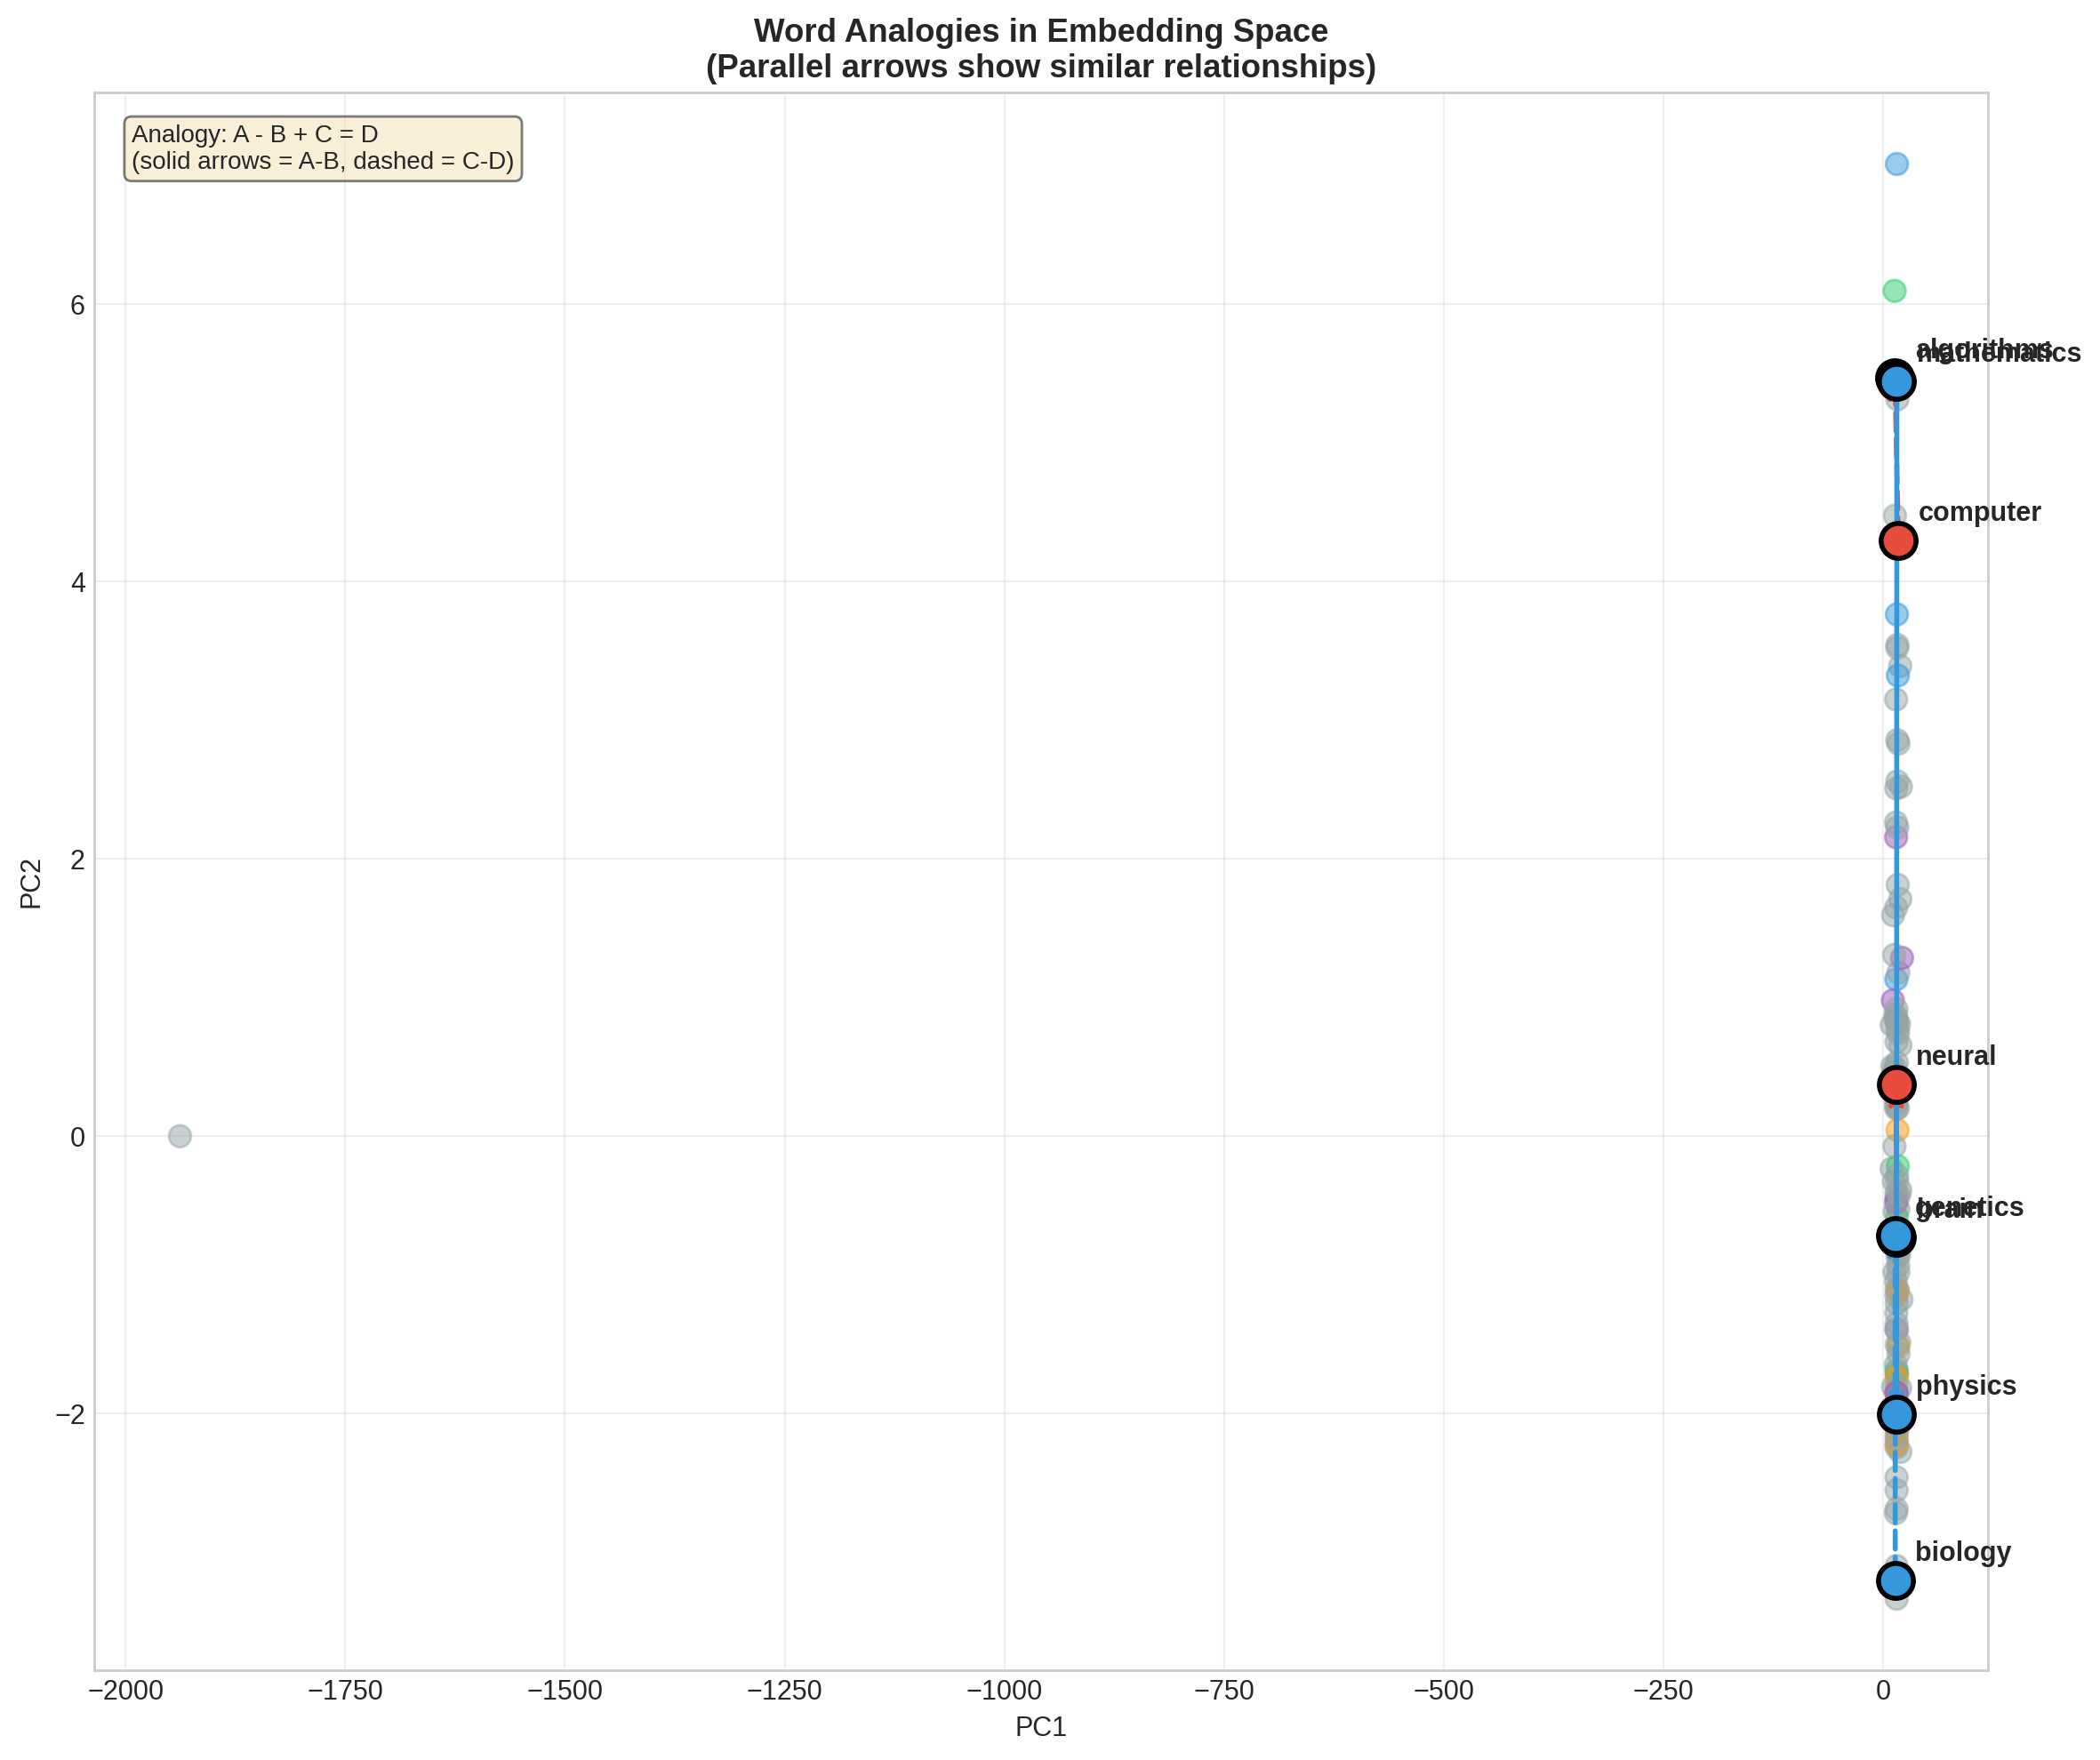

Saved: text_embeddings_analogy.png


In [13]:
# Plot 4: Analogy visualization
fig, ax = plt.subplots(figsize=(12, 10))

# Use PCA coordinates for visualization
# Show word relationships

# Draw all words
ax.scatter(pca_2d[:, 0], pca_2d[:, 1], c=word_colors, alpha=0.5, s=80)

# Highlight analogy words and draw arrows
analogy_sets = [
    ('neural', 'brain', 'computer', 'algorithms', '#e74c3c'),
    ('physics', 'mathematics', 'biology', 'genetics', '#3498db')
]

for w1, w2, w3, w4, color in analogy_sets:
    idx1 = preprocessor.get_word_index(w1)
    idx2 = preprocessor.get_word_index(w2)
    idx3 = preprocessor.get_word_index(w3)
    idx4 = preprocessor.get_word_index(w4)
    
    if all(idx >= 0 for idx in [idx1, idx2, idx3, idx4]):
        # Highlight these words
        for idx, word in [(idx1, w1), (idx2, w2), (idx3, w3), (idx4, w4)]:
            ax.scatter(pca_2d[idx, 0], pca_2d[idx, 1], c=color, s=200, 
                      edgecolors='black', linewidth=2, zorder=5)
            ax.annotate(word, (pca_2d[idx, 0], pca_2d[idx, 1]), 
                       fontsize=11, fontweight='bold',
                       xytext=(8, 8), textcoords='offset points')
        
        # Draw arrows showing analogy
        # Arrow from w2 to w1 (relationship to capture)
        ax.annotate('', xy=(pca_2d[idx1, 0], pca_2d[idx1, 1]),
                   xytext=(pca_2d[idx2, 0], pca_2d[idx2, 1]),
                   arrowprops=dict(arrowstyle='->', color=color, lw=2))
        
        # Arrow from w3 to w4 (parallel relationship)
        ax.annotate('', xy=(pca_2d[idx4, 0], pca_2d[idx4, 1]),
                   xytext=(pca_2d[idx3, 0], pca_2d[idx3, 1]),
                   arrowprops=dict(arrowstyle='->', color=color, lw=2, linestyle='--'))

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Word Analogies in Embedding Space\n(Parallel arrows show similar relationships)', fontweight='bold')
ax.grid(True, alpha=0.3)

# Add explanation
ax.text(0.02, 0.98, 'Analogy: A - B + C = D\n(solid arrows = A-B, dashed = C-D)',
       transform=ax.transAxes, fontsize=10, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f'{NOTEBOOK_DIR}/text_embeddings_analogy.png', dpi=150, 
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: text_embeddings_analogy.png")

## Summary

This notebook demonstrated key concepts in word embeddings:

1. **Text Preprocessing**: Tokenization, vocabulary building, word-to-index mapping

2. **Skip-gram Model**: 
   - Predict context words from center word
   - Negative sampling for efficient training
   - Learn dense vector representations

3. **Visualization**:
   - PCA for global structure (linear projection)
   - t-SNE for local clusters (non-linear)

4. **Applications**:
   - Semantic similarity via cosine distance
   - Word analogies through vector arithmetic

### Key Insights

- **Distributional Hypothesis**: Words appearing in similar contexts have similar meanings
- **Dense Representations**: Better than one-hot for ML models
- **Transfer Learning**: Pre-trained embeddings improve downstream NLP tasks

In [14]:
print("\n" + "=" * 70)
print("WORD EMBEDDINGS NOTEBOOK COMPLETE")
print("=" * 70)

print("""
Model Statistics:
  - Vocabulary size: {} words
  - Embedding dimension: {}
  - Training pairs: {}
  - Final loss: {:.4f}

Plots generated:
  1. text_embeddings_training.png - Training loss curve
  2. text_embeddings_visualization.png - PCA and t-SNE embeddings
  3. text_embeddings_similarity.png - Word similarity heatmap
  4. text_embeddings_analogy.png - Word analogy visualization

Key concepts:
  - Skip-gram model with negative sampling
  - Dimensionality reduction (PCA, t-SNE)
  - Cosine similarity for word comparison
  - Vector arithmetic for word analogies
""".format(preprocessor.vocab_size, EMBEDDING_DIM, len(training_pairs), model.losses[-1]))


WORD EMBEDDINGS NOTEBOOK COMPLETE

Model Statistics:
  - Vocabulary size: 126 words
  - Embedding dimension: 50
  - Training pairs: 628
  - Final loss: 11.9088

Plots generated:
  1. text_embeddings_training.png - Training loss curve
  2. text_embeddings_visualization.png - PCA and t-SNE embeddings
  3. text_embeddings_similarity.png - Word similarity heatmap
  4. text_embeddings_analogy.png - Word analogy visualization

Key concepts:
  - Skip-gram model with negative sampling
  - Dimensionality reduction (PCA, t-SNE)
  - Cosine similarity for word comparison
  - Vector arithmetic for word analogies

